# Final Assignment: Part 1 - Create Visualizations using Matplotlib, Seaborn & Folium

This notebook contains the required visualization tasks using Python, Matplotlib, Seaborn, and Folium.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display

sns.set_theme(style='whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


## Task 1.1 - Average Annual Automobile Sales

Create a year column and Average Annual Automobile Sales values, then visualize how automobile sales fluctuate from year to year.

In [2]:
# Yearly automobile sales data
annual_sales = pd.DataFrame({
    'Year': [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989],
    'Average_Annual_Automobile_Sales': [7500, 7200, 6100, 6800, 7900, 8300, 8100, 8700, 9200, 9600]
})

display(annual_sales)

,Year,Average_Annual_Automobile_Sales
0,1980,7500
1,1981,7200
2,1982,6100
3,1983,6800
4,1984,7900
5,1985,8300
6,1986,8100
7,1987,8700
8,1988,9200
9,1989,9600


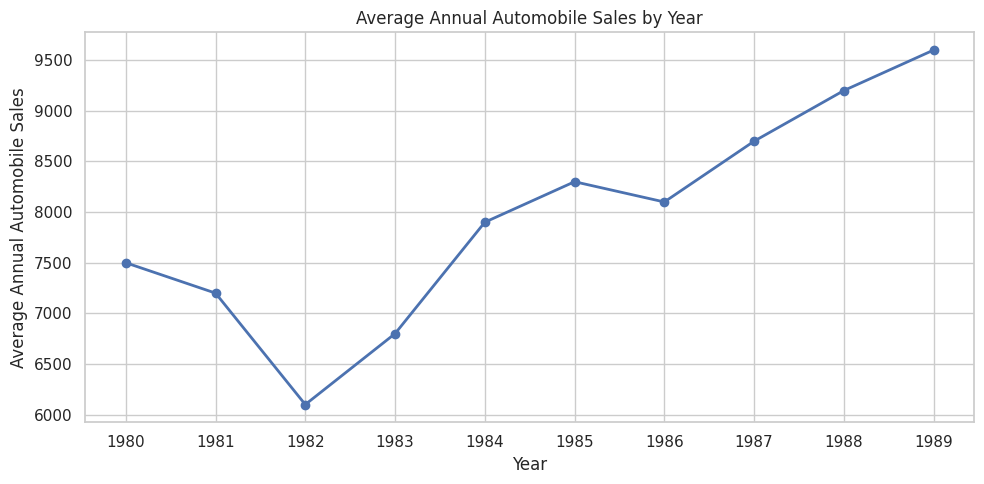

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(
    annual_sales['Year'],
    annual_sales['Average_Annual_Automobile_Sales'],
    marker='o',
    linewidth=2
)
plt.title('Average Annual Automobile Sales by Year')
plt.xlabel('Year')
plt.ylabel('Average Annual Automobile Sales')
plt.xticks(annual_sales['Year'])
plt.grid(True)
plt.tight_layout()
plt.show()

## Task 1.2 - Advertising Expenditure and Automobile Sales During Non-Recession Periods

Analyze whether advertising expenditure is associated with automobile sales during non-recession periods using a scatterplot, regression line, and correlation coefficient.

In [4]:
non_recession = pd.DataFrame({
    'Year': [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989],
    'Advertising_Expenditure': [120, 135, 150, 165, 180, 195, 210, 230, 250, 275],
    'Automobile_Sales': [3200, 3500, 3700, 3900, 4300, 4500, 4700, 5000, 5300, 5600]
})

correlation = non_recession['Advertising_Expenditure'].corr(non_recession['Automobile_Sales'])
print(f'Correlation coefficient: {correlation:.3f}')
display(non_recession)

Correlation coefficient: 0.997


,Year,Advertising_Expenditure,Automobile_Sales
0,1980,120,3200
1,1981,135,3500
2,1982,150,3700
3,1983,165,3900
4,1984,180,4300
5,1985,195,4500
6,1986,210,4700
7,1987,230,5000
8,1988,250,5300
9,1989,275,5600


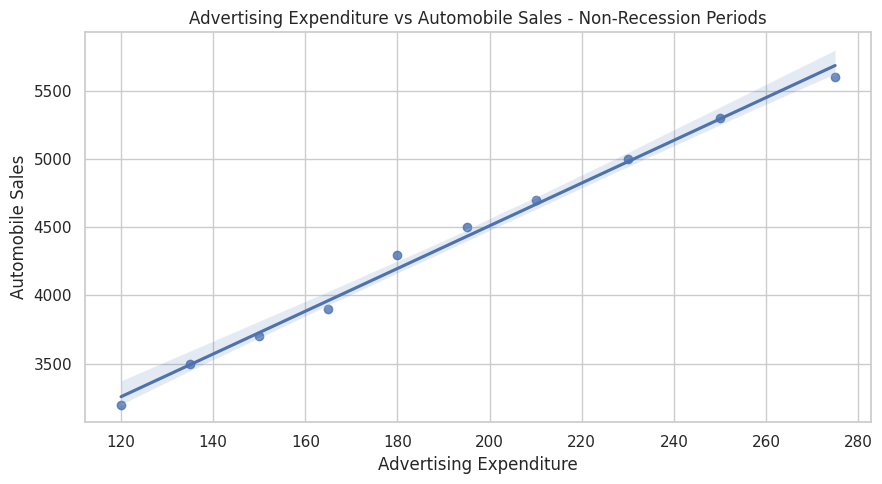

In [5]:
plt.figure(figsize=(9, 5))
sns.regplot(
    data=non_recession,
    x='Advertising_Expenditure',
    y='Automobile_Sales'
)
plt.title('Advertising Expenditure vs Automobile Sales - Non-Recession Periods')
plt.xlabel('Advertising Expenditure')
plt.ylabel('Automobile Sales')
plt.tight_layout()
plt.show()

## Task 1.3 - Vehicle-Wise Sales During Recession and Non-Recession Periods

Create a grouped bar chart comparing average vehicle sales during recession and non-recession periods.

In [6]:
vehicle_sales = pd.DataFrame({
    'Vehicle_Type': ['ExecutiveCar', 'MediumFamilyCar', 'SmallFamilyCar', 'Sports', 'SuperMiniCar'],
    'Non_Recession_Sales': [3330, 3850, 4020, 3430, 3750],
    'Recession_Sales': [830, 1680, 1660, 810, 2010]
})

display(vehicle_sales)

,Vehicle_Type,Non_Recession_Sales,Recession_Sales
0,ExecutiveCar,3330,830
1,MediumFamilyCar,3850,1680
2,SmallFamilyCar,4020,1660
3,Sports,3430,810
4,SuperMiniCar,3750,2010


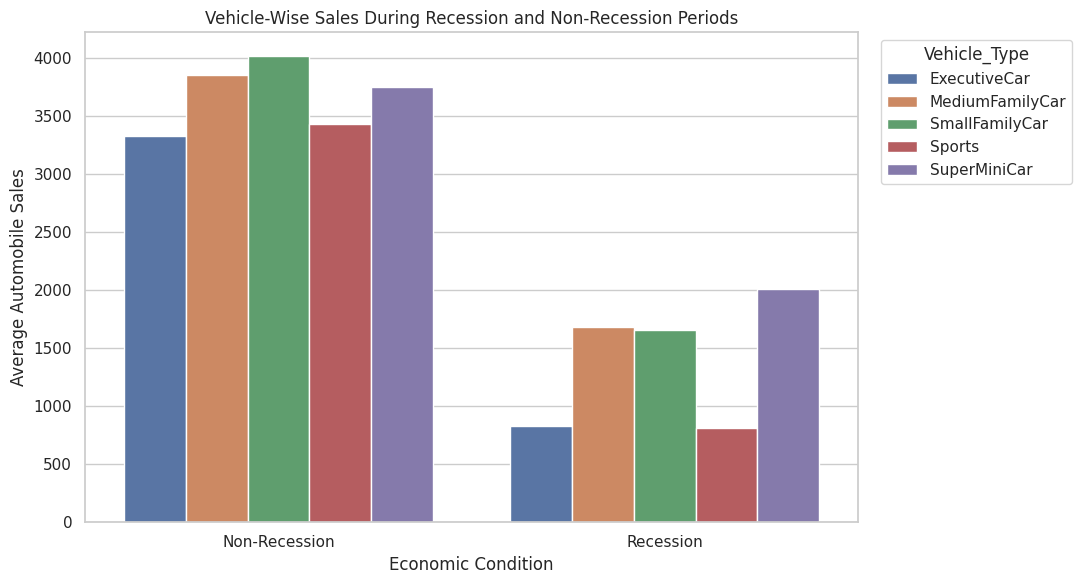

In [7]:
plot_data = vehicle_sales.melt(
    id_vars='Vehicle_Type',
    value_vars=['Non_Recession_Sales', 'Recession_Sales'],
    var_name='Economic_Condition',
    value_name='Average_Automobile_Sales'
)

plot_data['Economic_Condition'] = plot_data['Economic_Condition'].replace({
    'Non_Recession_Sales': 'Non-Recession',
    'Recession_Sales': 'Recession'
})

plt.figure(figsize=(11, 6))
sns.barplot(
    data=plot_data,
    x='Economic_Condition',
    y='Average_Automobile_Sales',
    hue='Vehicle_Type'
)
plt.title('Vehicle-Wise Sales During Recession and Non-Recession Periods')
plt.xlabel('Economic Condition')
plt.ylabel('Average Automobile Sales')
plt.legend(title='Vehicle_Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Task 1.4 - GDP Variation During Recession and Non-Recession Periods

Compare GDP values during recession and non-recession periods.

In [8]:
gdp_data = pd.DataFrame({
    'Economic_Condition': [
        'Non-Recession', 'Non-Recession', 'Non-Recession', 'Non-Recession',
        'Recession', 'Recession', 'Recession', 'Recession'
    ],
    'Year': [1980, 1981, 1983, 1984, 1982, 1990, 1991, 2008],
    'GDP': [5.2, 5.5, 6.1, 6.5, 4.1, 5.8, 5.2, 4.7]
})

gdp_summary = gdp_data.groupby('Economic_Condition')['GDP'].agg(['mean', 'min', 'max']).reset_index()
print('GDP summary by economic condition:')
display(gdp_summary)

GDP summary by economic condition:


,Economic_Condition,mean,min,max
0,Non-Recession,5.825,5.2,6.5
1,Recession,4.950,4.1,5.8


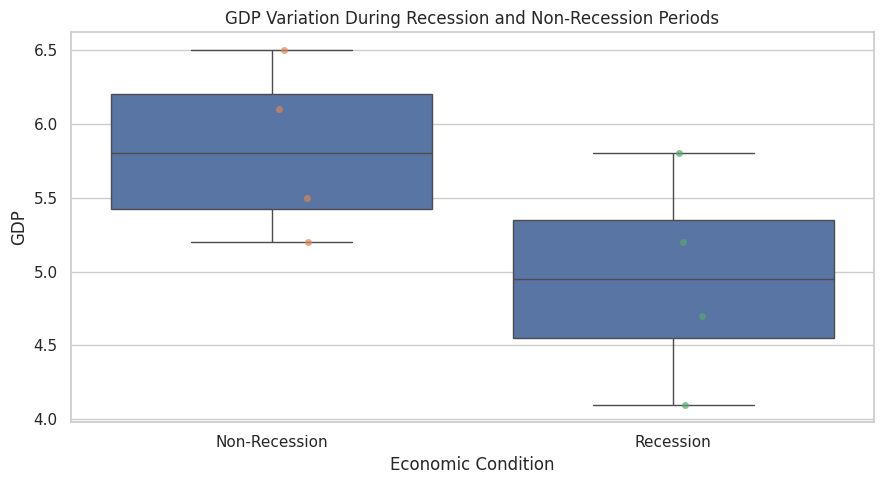

In [9]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=gdp_data, x='Economic_Condition', y='GDP')
sns.stripplot(data=gdp_data, x='Economic_Condition', y='GDP', alpha=0.7)
plt.title('GDP Variation During Recession and Non-Recession Periods')
plt.xlabel('Economic Condition')
plt.ylabel('GDP')
plt.tight_layout()
plt.show()

## Task 1.5 - Bubble Plot for Seasonality Impact on Automobile Sales

A bubble plot uses marker size to represent automobile sales and helps visualize seasonal variation.

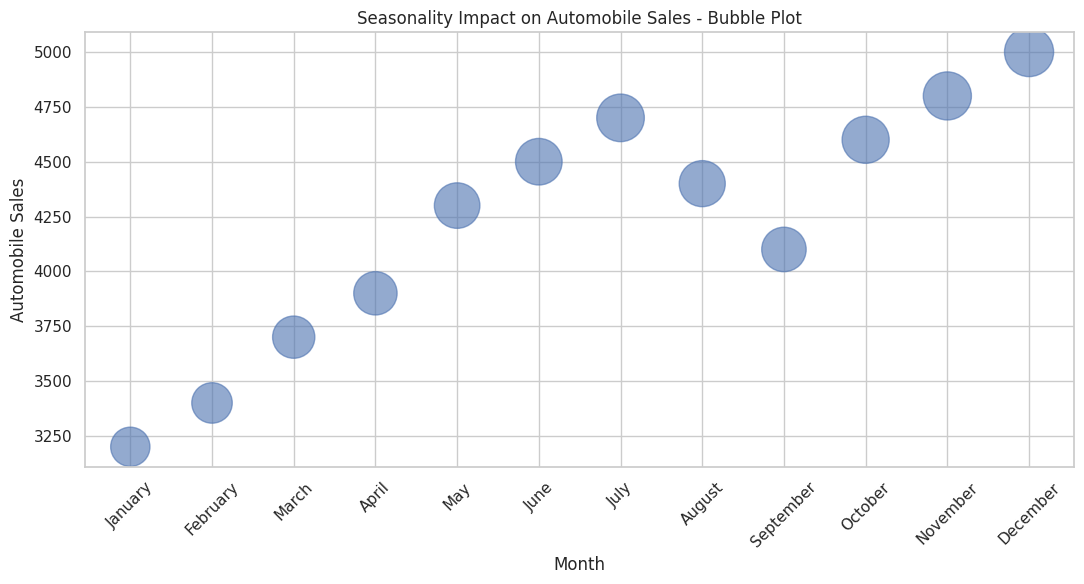

In [10]:
seasonal_sales = pd.DataFrame({
    'Month': ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December'],
    'Season': ['Winter', 'Winter', 'Spring', 'Spring', 'Summer', 'Summer',
               'Summer', 'Monsoon', 'Monsoon', 'Autumn', 'Autumn', 'Winter'],
    'Automobile_Sales': [3200, 3400, 3700, 3900, 4300, 4500,
                         4700, 4400, 4100, 4600, 4800, 5000]
})

plt.figure(figsize=(11, 6))
plt.scatter(
    seasonal_sales['Month'],
    seasonal_sales['Automobile_Sales'],
    s=seasonal_sales['Automobile_Sales'] / 4,
    alpha=0.6
)
plt.title('Seasonality Impact on Automobile Sales - Bubble Plot')
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 1.6 - Relationship Between Price and Automobile Sales During Recession

Use recession-period price and automobile sales data to examine their relationship.

In [11]:
recession_price_sales = pd.DataFrame({
    'Price': [18, 20, 22, 24, 26, 28, 30, 32, 35, 38],
    'Automobile_Sales': [2300, 2200, 2050, 1900, 1750, 1600, 1450, 1300, 1150, 1000]
})

display(recession_price_sales)

,Price,Automobile_Sales
0,18,2300
1,20,2200
2,22,2050
3,24,1900
4,26,1750
5,28,1600
6,30,1450
7,32,1300
8,35,1150
9,38,1000


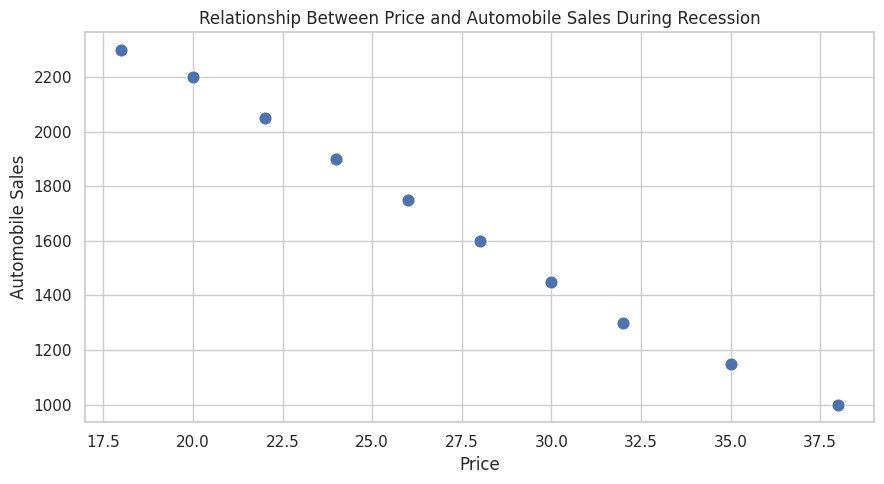

Price-Sales correlation during recession: -0.997


In [12]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=recession_price_sales,
    x='Price',
    y='Automobile_Sales',
    s=90
)
plt.title('Relationship Between Price and Automobile Sales During Recession')
plt.xlabel('Price')
plt.ylabel('Automobile Sales')
plt.tight_layout()
plt.show()

price_sales_corr = recession_price_sales['Price'].corr(
    recession_price_sales['Automobile_Sales']
)
print(f'Price-Sales correlation during recession: {price_sales_corr:.3f}')

## Additional Visualization - Interactive Folium Map

An interactive map is included to demonstrate the use of Folium.

In [13]:
locations = {
    'Delhi': [28.6139, 77.2090],
    'Mumbai': [19.0760, 72.8777],
    'Bengaluru': [12.9716, 77.5946],
    'Chennai': [13.0827, 80.2707],
    'Kolkata': [22.5726, 88.3639],
    'Hyderabad': [17.3850, 78.4867]
}

m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)
for city, coordinates in locations.items():
    folium.Marker(
        coordinates,
        popup=city,
        tooltip=f'Sales location: {city}'
    ).add_to(m)

m

## Conclusion

The notebook demonstrates three key analyses: yearly fluctuations in average automobile sales, the relationship between advertising expenditure and sales during non-recession periods, and vehicle-wise sales comparisons between recession and non-recession periods.